### Importing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### EDA

In [4]:
df.shape

(200, 4)

In [5]:
df.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


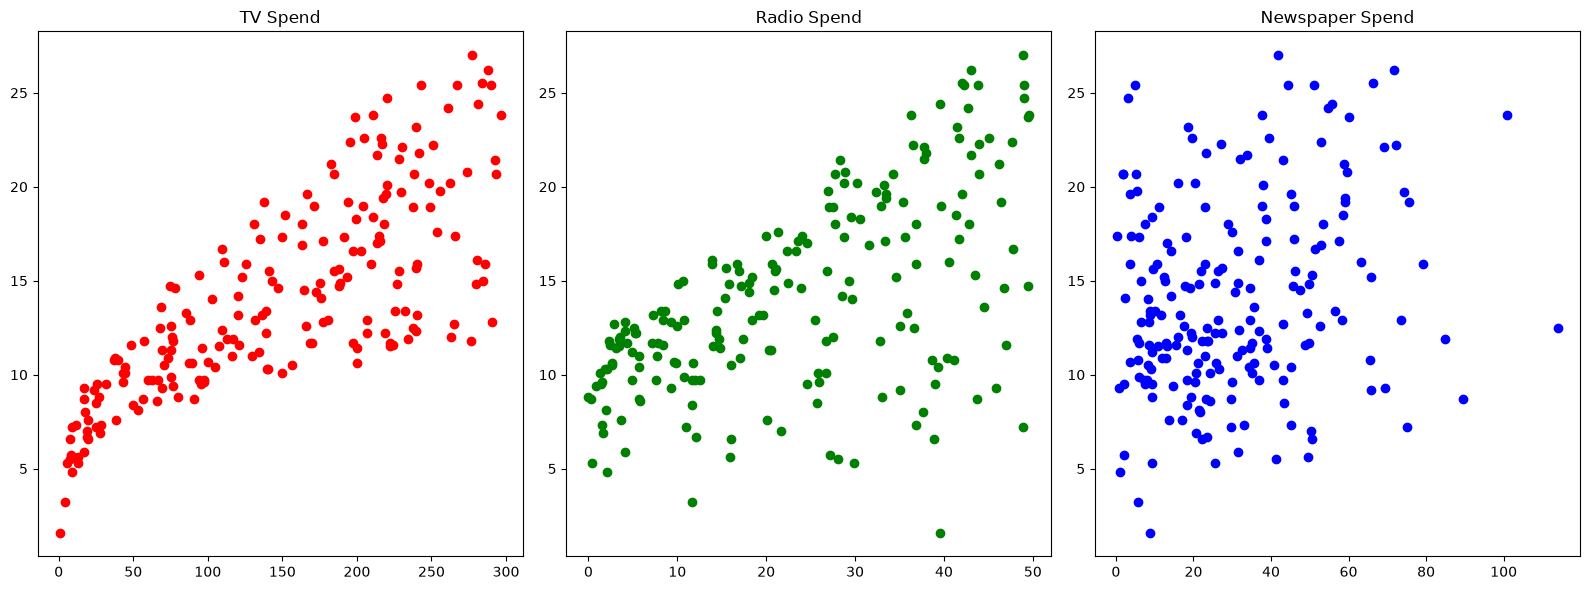

In [11]:
fig , axes = plt.subplots(nrows = 1 , ncols = 3 , figsize = (16 , 6))

axes[0].scatter(df["TV"] , df["sales"] , color = "red")
axes[0].set_title("TV Spend")

axes[1].scatter(df["radio"] , df["sales"] , color = "green")
axes[1].set_title("Radio Spend")

axes[2].scatter(df["newspaper"] , df["sales"] , color = "blue")
axes[2].set_title("Newspaper Spend")

plt.tight_layout()

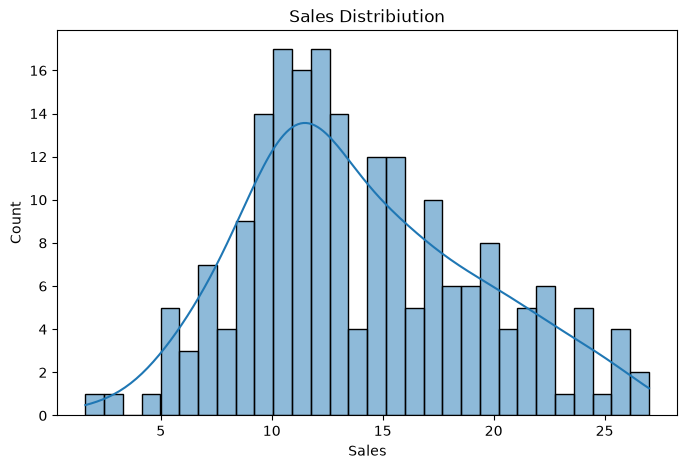

In [15]:
plt.figure(figsize = (8 , 5))
sns.histplot(df["sales"] , bins = 30 , kde = True);

plt.title("Sales Distribiution")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.show()

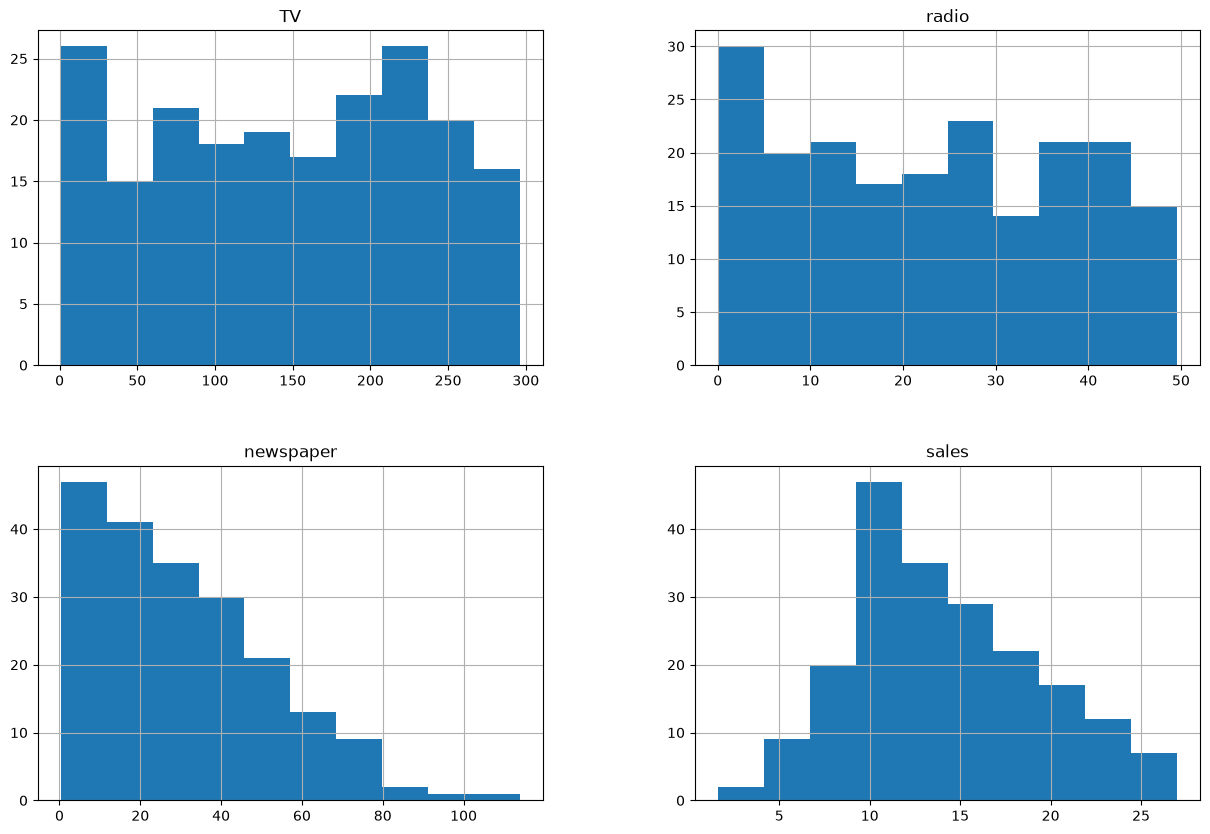

In [17]:
df.hist(figsize = (15 , 10))
plt.show()

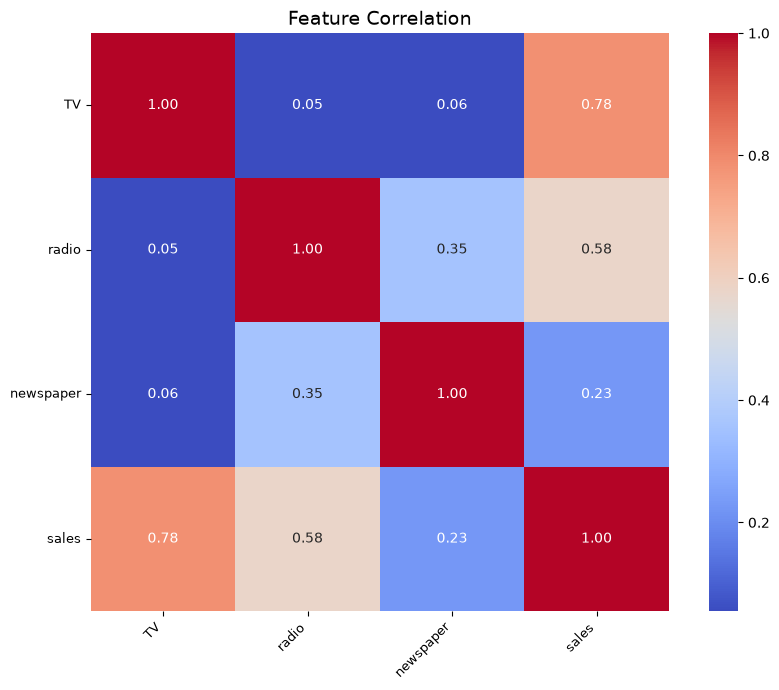

In [20]:
plt.figure(figsize = (9 , 7))
sns.heatmap(df.corr() , annot = True , fmt = ".2f" , cmap = "coolwarm" , square = True)

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(rotation = 0 , fontsize = 9)
plt.tight_layout()
plt.show()

### Feature & Target Split

In [22]:
X = df.drop(columns = ["sales"])
y = df["sales"]

### Polynomial Features

In [23]:
poly_converter = PolynomialFeatures(degree = 2 , include_bias = False)
poly_features = poly_converter.fit_transform(X)

### Train & Test Split

In [24]:
X_train , X_test , y_train , y_test = train_test_split(poly_features , y , test_size = 0.2 , random_state = 101)

### Standard Scaler

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Model Training

In [26]:
final_model = LinearRegression(fit_intercept = True)
final_model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Prediction

In [27]:
y_pred = final_model.predict(X_test)

### Evaluation

In [29]:
print("Final Model : Polynomial Regression")
print(f"MAE : {mean_absolute_error(y_test , y_pred)}")
print(f"MSE : {mean_squared_error(y_test , y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test , y_pred)}")
print(f"R2 Score : {r2_score(y_test , y_pred)}")

Final Model : Polynomial Regression
MAE : 0.44310658314798956
MSE : 0.33749720374186165
RMSE : 0.5809450952903051
R2 Score : 0.9886020119729051


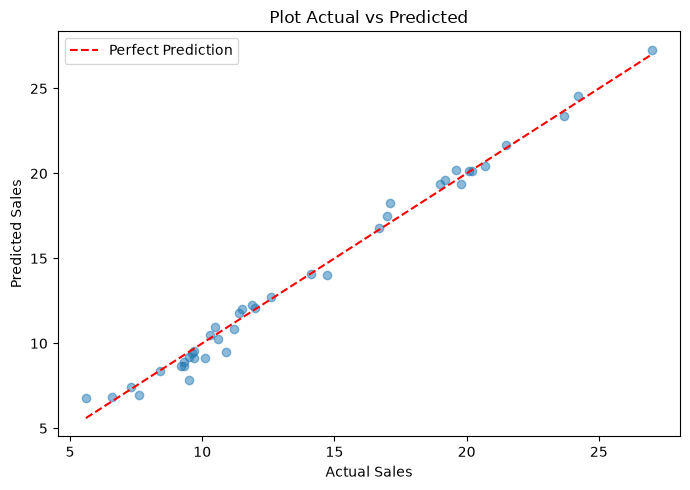

In [32]:
plt.figure(figsize = (7 , 5))
plt.scatter(y_test , y_pred , alpha = 0.5)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color = "red" , linestyle = "--" , label = "Perfect Prediction")

plt.title("Plot Actual vs Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.legend()
plt.show()

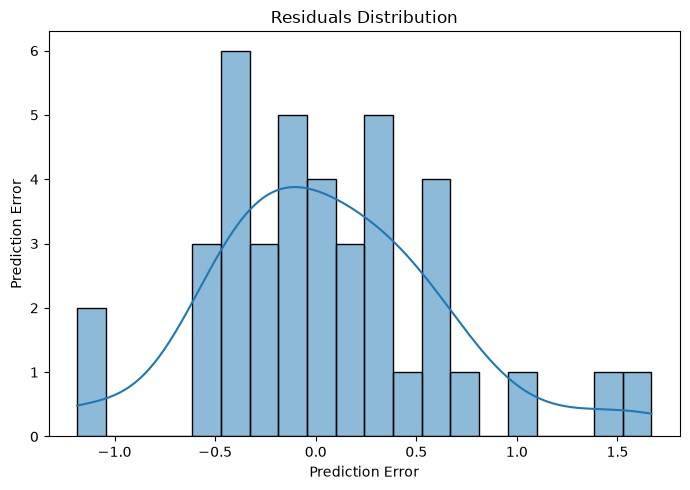

In [35]:
residuals = y_test - y_pred

plt.figure(figsize = (7 , 5))
sns.histplot(residuals , bins = 20 , kde = True)

plt.title("Residuals Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Prediction Error")
plt.tight_layout()
plt.show()